## NBA Exploratory Data Analysis
<img src = "NBA_Logo.png" width = "400" height = "200">

*The National Basketball Association, or NBA, is a professional basketball league comprised of 30 teams across North America featuring the best basketball players in the world.* (NBA.com)


 In this project, I will be analyzing NBA Teams and their statistics to identify what separates NBA winners from losers. The core question I will be answering is: **Across the 2024-2025 season, which stats most strongly correlate with winning?** 


Data is sourced live from the NBA Stats API using the nba_api Python Library, covering all 30 teams across the 2024-2025 regular season.

### Data Exploration
We begin by importing significant modules, then fetching and exploring data from the API.

In [57]:
from nba_api.stats.static import teams
from nba_api.stats.endpoints import teamgamelog
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time

all_teams = teams.get_teams()
print(f"Total teams: {len(all_teams)}")

all_gamelogs = []

for team in all_teams:
    time.sleep(1)  # pause after every API fetch
    log = teamgamelog.TeamGameLog(team_id = team['id'], season='2024-25')
    df = log.get_data_frames()[0]
    df['team_name'] = team['full_name']
    all_gamelogs.append(df) # all dataframes in df

master_df = pd.concat(all_gamelogs, ignore_index=True)
print(f"\nDone! Shape: {master_df.shape}")

master_df.to_csv('nba_gamelogs.csv', index=False)


Total teams: 30

Done! Shape: (2460, 28)


In [58]:
master_df.head()

,Team_ID,Game_ID,GAME_DATE,MATCHUP,WL,W,L,W_PCT,MIN,FGM,...,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PTS,team_name
0,1610612737,0022401186,"APR 13, 2025",ATL vs. ORL,W,40,42,0.488,240,47,...,9,35,44,32,8,2,15,15,117,Atlanta Hawks
1,1610612737,0022401173,"APR 11, 2025",ATL @ PHI,W,39,42,0.481,240,45,...,18,35,53,28,9,5,14,15,124,Atlanta Hawks
2,1610612737,0022401169,"APR 10, 2025",ATL @ BKN,W,38,42,0.475,240,48,...,7,44,51,36,11,1,15,19,133,Atlanta Hawks
3,1610612737,0022401149,"APR 08, 2025",ATL @ ORL,L,37,42,0.468,240,40,...,14,27,41,25,7,6,18,26,112,Atlanta Hawks
4,1610612737,0022401136,"APR 06, 2025",ATL vs. UTA,W,37,41,0.474,240,54,...,11,31,42,43,7,3,11,19,147,Atlanta Hawks


In [59]:
master_df.dtypes

Team_ID        int64
Game_ID          str
GAME_DATE        str
MATCHUP          str
WL               str
W              int64
L              int64
W_PCT        float64
MIN            int64
FGM            int64
FGA            int64
FG_PCT       float64
FG3M           int64
FG3A           int64
FG3_PCT      float64
FTM            int64
FTA            int64
FT_PCT       float64
OREB           int64
DREB           int64
REB            int64
AST            int64
STL            int64
BLK            int64
TOV            int64
PF             int64
PTS            int64
team_name        str
dtype: object

In [60]:
master_df.isnull().sum()

Team_ID      0
Game_ID      0
GAME_DATE    0
MATCHUP      0
WL           0
W            0
L            0
W_PCT        0
MIN          0
FGM          0
FGA          0
FG_PCT       0
FG3M         0
FG3A         0
FG3_PCT      0
FTM          0
FTA          0
FT_PCT       0
OREB         0
DREB         0
REB          0
AST          0
STL          0
BLK          0
TOV          0
PF           0
PTS          0
team_name    0
dtype: int64

**⭐️ Key Insights:** 


The dataset contains 2460 rows and 28 columns. Each column provides important information about each game:
- Identity columns: Team_ID, Game_ID, GAME_DATE, MATCHUP, team_name
- Outcome columns: WL (win or lose), W (total wins), L (total losses), W_PCT (win percentage so far)
- Box score columns: 
    - MIN                    (minutes played)
    - FGM, FGA, FG_PCT       (field goals made, attempted, percentage)
    - FG3M, FG3A, FG3_PCT    (three pointers made, attempted, percentage)
    - FTM, FTA, FT_PCT       (free throws made, attempted, percentage)
    - OREB, DREB, REB        (rebounds, offensive, defensive) 
    - AST                    (assists)
    - STL, BLK               (steals, blocks)
    - TOV                    (turnovers) 
    - PF                     (personal fouls)
    - PTS                    (points)

Fortunately, there are no missing values. Therefore, the data is ready for aggregation.

### Data Aggregation

Currently the dataset has 2,460 rows — one row per game. To compare teams against each other, we collapse this into 30 rows, one per team, containing season averages for each stat.

In [61]:
# Since the win percentage (W_PCT) is the cumulative percentage after each game, we compute 
# for the final win percentage at the end of the season using the 'WL' column in master_df.

master_df['W_PCT'] = (master_df['WL'] == 'W').astype(int) # binary indicator

no_avg = ["Team_ID", "Game_ID", "GAME_DATE", "MATCHUP", "WL"] # columns with no need to average
team_avgs = (master_df.drop(columns=no_avg).groupby("team_name").mean(numeric_only=True))
team_avgs.to_csv("nba_averages.csv", index=False)
team_avgs.head()

# Note that although the column is named W_PCT in master_df, we change its values to binary 
# indicators, where 1 represents a win and 0 represents a loss, so they are no longer percentages. 
# This is done so that game outcomes can be used in numerical analysis, such as computing 
# correlations and averaging values when grouping by team.

,W,L,W_PCT,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,...,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PTS
team_name,,,,,,,,,,,,,,,,,,,,,
Atlanta Hawks,19.902439,21.597561,0.487805,241.219512,43.365854,91.804878,0.473622,13.500000,37.670732,0.357061,...,0.773817,11.878049,32.621951,44.500000,29.585366,9.731707,5.109756,14.695122,19.073171,118.182927
Boston Celtics,30.353659,11.146341,0.743902,241.829268,41.621951,90.024390,0.463122,17.768293,48.231707,0.369073,...,0.800695,11.378049,33.939024,45.317073,26.146341,7.182927,5.512195,11.353659,15.890244,116.268293
Brooklyn Nets,14.365854,27.134146,0.317073,241.219512,37.634146,86.097561,0.438220,13.573171,39.414634,0.342354,...,0.785159,10.902439,30.402439,41.304878,25.158537,7.792683,4.292683,13.878049,20.707317,105.109756
Charlotte Hornets,10.658537,30.841463,0.231707,240.914634,38.317073,89.121951,0.430951,12.987805,38.329268,0.337207,...,0.779293,12.231707,32.963415,45.195122,24.317073,7.402439,4.487805,14.865854,18.719512,105.097561
Chicago Bulls,17.780488,23.719512,0.475610,240.914634,43.207317,92.012195,0.470585,15.439024,42.036585,0.368451,...,0.809293,10.060976,35.792683,45.853659,29.060976,7.573171,4.707317,13.939024,17.609756,117.804878


In [62]:
# Teams with highest win percentages
team_avgs.sort_values(by="W_PCT", ascending=False).head()


,W,L,W_PCT,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,...,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PTS
team_name,,,,,,,,,,,,,,,,,,,,,
Oklahoma City Thunder,34.219512,7.280488,0.829268,240.304878,44.634146,92.682927,0.482073,14.536585,38.829268,0.373646,...,0.819049,10.621951,34.158537,44.780488,26.853659,10.329268,5.670732,11.024390,19.890244,120.500000
Cleveland Cavaliers,34.597561,6.902439,0.780488,240.914634,44.536585,90.780488,0.491451,15.890244,41.475610,0.384610,...,0.771732,11.182927,34.219512,45.402439,28.097561,8.170732,4.268293,12.536585,18.134146,121.939024
Boston Celtics,30.353659,11.146341,0.743902,241.829268,41.621951,90.024390,0.463122,17.768293,48.231707,0.369073,...,0.800695,11.378049,33.939024,45.317073,26.146341,7.182927,5.512195,11.353659,15.890244,116.268293
Houston Rockets,26.804878,14.695122,0.634146,241.219512,42.487805,93.402439,0.455122,12.658537,35.829268,0.352537,...,0.740317,14.634146,33.829268,48.463415,23.341463,8.402439,5.012195,13.036585,18.987805,114.292683
New York Knicks,26.475610,15.024390,0.621951,242.439024,43.329268,89.207317,0.486671,12.573171,34.073171,0.366232,...,0.801293,10.853659,31.792683,42.646341,27.487805,8.182927,3.951220,12.182927,17.158537,115.780488


In [63]:
# Teams with lowest win percentages
team_avgs.sort_values(by="W_PCT", ascending=False).tail()

,W,L,W_PCT,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,...,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PTS
team_name,,,,,,,,,,,,,,,,,,,,,
Philadelphia 76ers,14.121951,27.378049,0.292683,241.524390,39.682927,87.414634,0.454878,12.695122,37.195122,0.340780,...,0.782573,10.390244,29.402439,39.792683,23.182927,9.170732,4.463415,12.841463,18.975610,109.609756
New Orleans Pelicans,10.292683,31.207317,0.256098,240.914634,40.634146,89.853659,0.452463,12.024390,34.621951,0.344854,...,0.751683,12.109756,31.500000,43.609756,25.841463,8.548780,5.231707,13.939024,18.280488,109.829268
Charlotte Hornets,10.658537,30.841463,0.231707,240.914634,38.317073,89.121951,0.430951,12.987805,38.329268,0.337207,...,0.779293,12.231707,32.963415,45.195122,24.317073,7.402439,4.487805,14.865854,18.719512,105.097561
Washington Wizards,7.743902,33.756098,0.219512,240.609756,39.426829,89.890244,0.439110,13.109756,39.146341,0.332976,...,0.771268,10.573171,33.121951,43.695122,25.097561,7.597561,5.121951,14.914634,19.731707,108.000000
Utah Jazz,9.439024,32.060976,0.207317,241.524390,40.304878,88.682927,0.456146,13.951220,39.841463,0.352890,...,0.774634,11.987805,33.426829,45.414634,25.524390,6.768293,4.390244,16.463415,18.890244,111.890244


### Data Analysis
In this section, we now explore the relationships between various game statistics and winning outcomes across the 2024-2025 NBA season. The goal here is to identify which team performance metrics and most strongly associated with success. To do this, we first analyze the correlation between each statistic and game results to quantify the strength of their relationships with winning.


In addition to numerical analysis, we use data visualization techniques to better understand these patterns. By creating graphs such as boxplots, we can compare how different statistics vary between wins and losses. This allows us to move beyond numbers and observe clear trends in team performance. 


We first oberserve correlation at game level instead of using team averages.

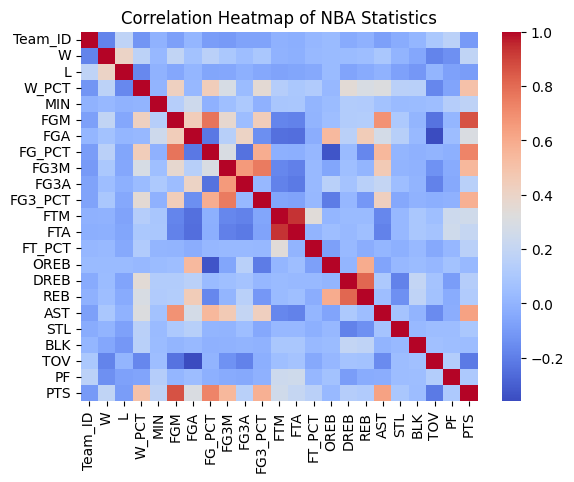

In [67]:
# Heatmap visualization
corr_matrix = master_df.corr(numeric_only=True)
sns.heatmap(corr_matrix, cmap="coolwarm")
plt.title("Correlation Heatmap of NBA Statistics")
plt.show()

The heatmap visualizes the correlation between all numeric statistics in the dataset. The diagonal red line represents perfect self-correlation, where each variable is perfectly correlated with itself (correlation = 1).


Focusing on the row for win percentage (W_PCT), we see how each statistic relates to winning games (W_PCT = 1 for wins and 0 for losses). The strongest positive correlation is with points scored (PTS), suggesting that teams tend to score more points in the games they win. This makes intuitive sense, as scoring more points increased the likelihood of outperforming the opponent. 


On the other hand, turnovers (TOV) show a negative correlation with W_PCT, indicating that teams committing more turnovers are more likely to lose. This reflects the importance of ball control in winning games.


Other statistics, such as free throws and rebounds, show a weaker correlation with W_PCT. This suggests that their relationship with winning is less significant or more context dependent compared to scoring and turnovers. 


To further understand scoring, we shift our focus to the PTS row. Here, points scored is most strongly positively correlated with field goals made (FGM), which is expected since field goals are a primary source of points.

Another way of seeing these observations is by using a bar chart.

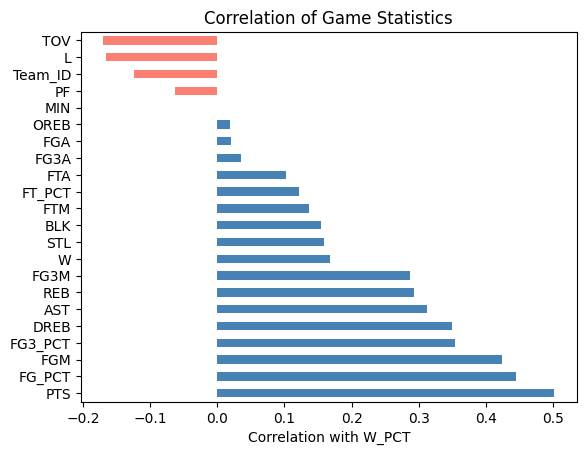

In [82]:
corr_with_wins = master_df.corr(numeric_only=True)["W_PCT"].drop("W_PCT").sort_values(ascending=False)
colors = ['steelblue' if v > 0 else 'salmon' for v in corr_with_wins]
corr_with_wins.plot(kind='barh', color=colors)
plt.title('Correlation of Game Statistics')
plt.xlabel('Correlation with W_PCT')
plt.show()

This chart clearly shows each statistic's correlation with winning, where positive values (blue) indicate stats associated with wins, and negative values (red) indicate stats associated with losses. This is consistent with the insights we gained from the heatmap: turnovers have the strongest negative correlation with W_PCT while points scored have the strongest positive correlation with W_PCT.


Now we will analyze game statistics in team-level.

Text(0, 0.5, 'W_PCT')

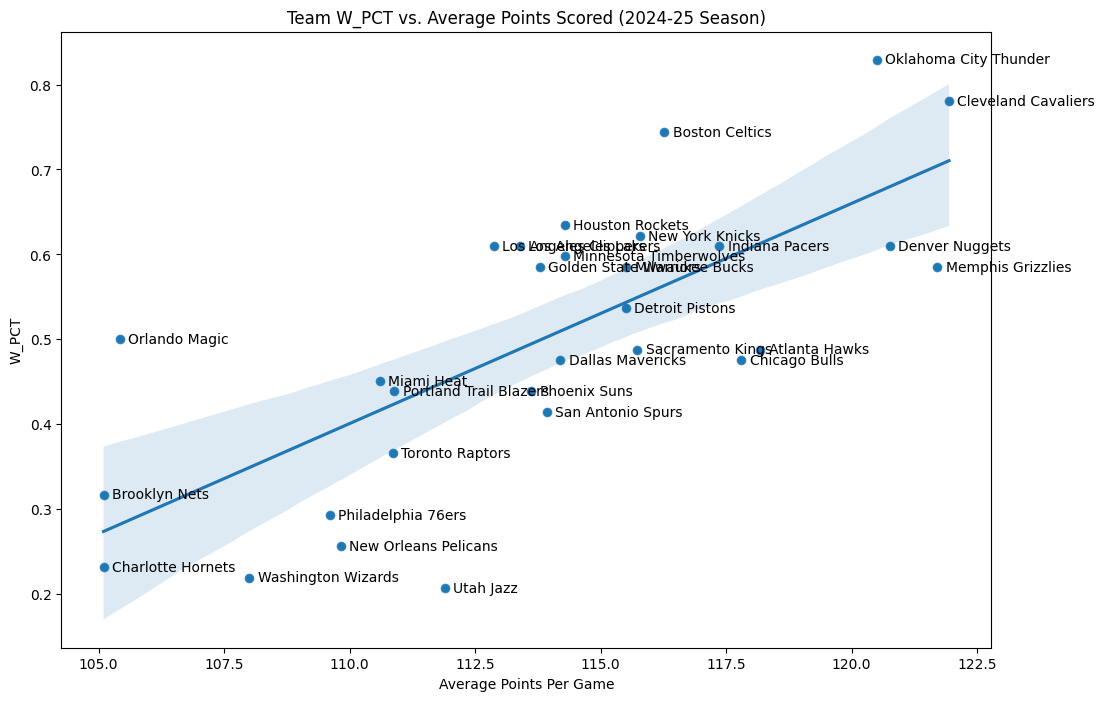

In [105]:
plt.figure(figsize=(12,8))
sns.scatterplot(data=team_avgs, x="PTS", y="W_PCT")

for team, row in team_avgs.iterrows():
    plt.annotate(team, (row['PTS'], row['W_PCT']), xytext=(6,-3), textcoords="offset points")

sns.regplot(data=team_avgs, x="PTS", y="W_PCT")
plt.title('Team W_PCT vs. Average Points Scored (2024-25 Season)')
plt.xlabel('Average Points Per Game')
plt.ylabel('W_PCT')

Clearly, there is a positive relationship between points scored and win percentage, confirmed by the regression line. However, the relationship is not perfect. Some teams score high a high level of points but still shows a weaker correlation with W_PCT. This suggests that other player factors, such as defense, pace of play, or shot quality influence game wins.

Text(0, 0.5, 'W_PCT')

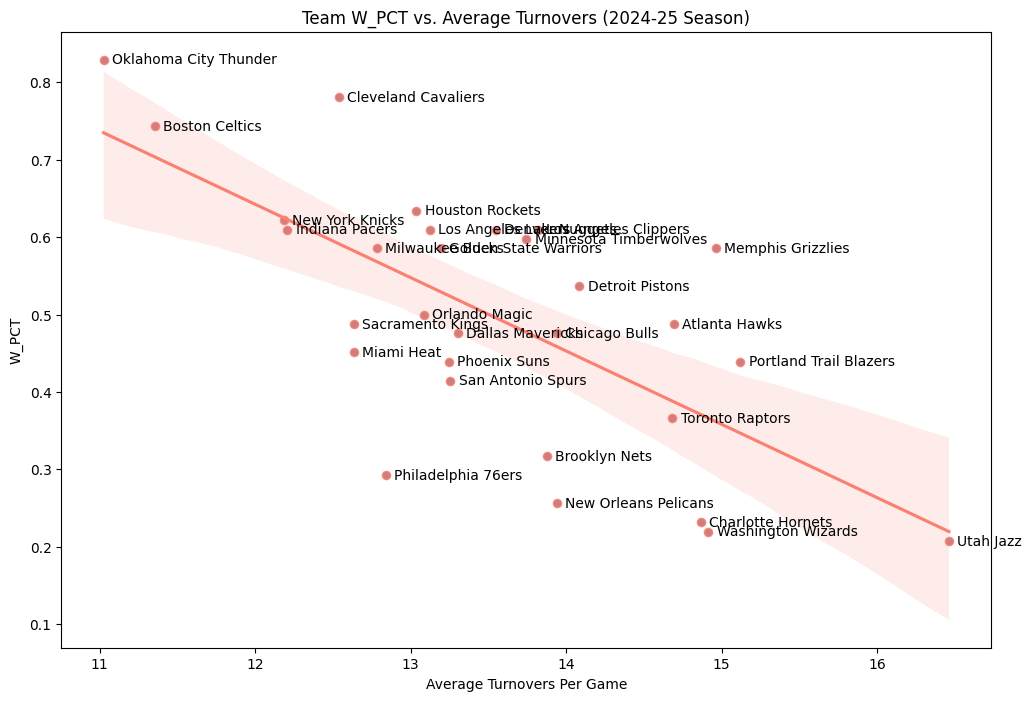

In [107]:
plt.figure(figsize=(12,8))
sns.scatterplot(data=team_avgs, x="TOV", y="W_PCT")

for team, row in team_avgs.iterrows():
    plt.annotate(team, (row['TOV'], row['W_PCT']), xytext=(6,-3), textcoords="offset points")

sns.regplot(data=team_avgs, x="TOV", y="W_PCT", color='salmon')
plt.title('Team W_PCT vs. Average Turnovers (2024-25 Season)')
plt.xlabel('Average Turnovers Per Game')
plt.ylabel('W_PCT')

As expected from the game-level analysis, teams with fewer turnovers on average tend to win more. The negative regression slope confirmes this relationship. This means that ball control appears to be a consistent differentiator, where winning teams not only score efficiently but also protect possessions.

### Conclusion
This analysis explored team and game-level performance data across the 2024-25 NBA season to identify which statistics are most strongly associated with winning. By collecting data through the NBA API and aggregating 2,460 game records across all 30 teams, we were able to examine seasonal trends and correlations at scale.


The correlation heatmap revealed that points scored (PTS) is the strongest positive predictor of winning, while turnovers (TOV) show the most notable negative relationship with game outcomes. Other statistics such as rebounds and free throws showed weaker or more context-dependent associations with winning.


Overall, the findings suggest that offensive efficiency and ball control are the two most consistent differentiators between wins and losses in the NBA.